In [1]:
import warnings  #This module is used to show warning messages
warnings.filterwarnings("ignore")


In [2]:
#BASIC LIBRARIES
import pandas as pd
import numpy as np

#Visualization Libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [3]:
#Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [4]:
fashion_train = pd.read_csv("fashion-mnist_train.csv")
fashion_test = pd.read_csv("fashion-mnist_test.csv")

In [11]:
fashion_train.shape

(60000, 785)

In [12]:
fashion_test.shape

(10000, 785)

In [13]:
#Spliting dataset
X_train_fashion = fashion_train.drop('label',axis=1)
y_train_fashion = fashion_train['label']
X_test_fashion = fashion_test.drop('label',axis=1)
y_test_fashion = fashion_test['label']

In [14]:
X_train_fashion

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,5,0,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,1,2,0,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,0,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,0,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:

#Reshaping the dataset
x_train_reshape = X_train_fashion.values.reshape(-1,28,28)
x_test_reshape = X_test_fashion.values.reshape(-1,28,28)

In [16]:
x_train_reshape


array([[[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       ...,

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0

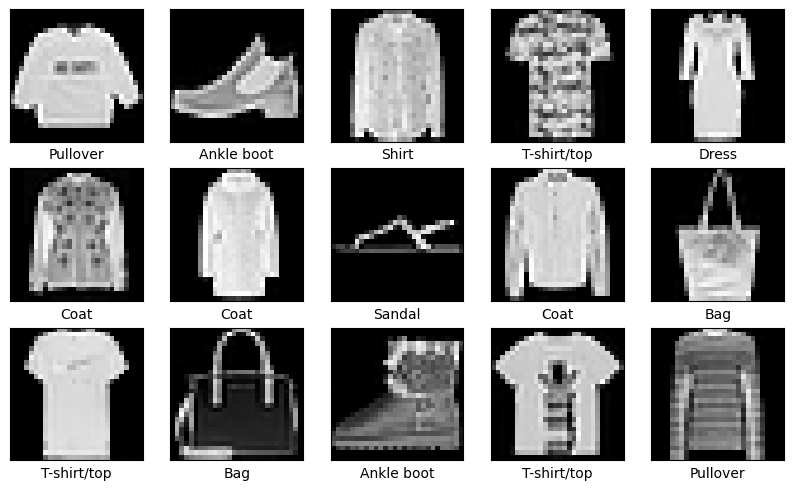

In [17]:
#names of clothing accessories in the dataset in order
col_names= ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Visualization of data
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train_reshape[i],cmap='gray')
    plt.xlabel(col_names[y_train_fashion[i]])
plt.show()

In [18]:
#Encoding fashion mnist labels using one hot encoding for ANN
y_train_fashion = to_categorical(y_train_fashion,num_classes = 10)
y_test_fashion = to_categorical(y_test_fashion, num_classes = 10)

In [19]:
y_train_fashion.shape

(60000, 10)

In [20]:
#Creating base for neural network
model = keras.Sequential([layers.Dense(128,activation = 'relu',input_shape = (784,)),
                          layers.Dropout(0.3),
                          layers.BatchNormalization(),
                          layers.Dense(24,activation = 'relu'),
                          layers.Dropout(0.3),
                          layers.BatchNormalization(),
                          layers.Dense(24,activation = 'relu'),
                          layers.Dropout(0.3),
                          layers.BatchNormalization(),
                          layers.Dense(10,activation = 'softmax')])
#compiling the model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics = ['accuracy'])

#fitting the model
history= model.fit(X_train_fashion,y_train_fashion,batch_size=100,epochs=30,validation_data=(X_test_fashion,y_test_fashion))

Epoch 1/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.6253 - loss: 1.1125 - val_accuracy: 0.8231 - val_loss: 0.5394
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7517 - loss: 0.7320 - val_accuracy: 0.8400 - val_loss: 0.4616
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7772 - loss: 0.6585 - val_accuracy: 0.8457 - val_loss: 0.4352
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7923 - loss: 0.6200 - val_accuracy: 0.8535 - val_loss: 0.4225
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7984 - loss: 0.6015 - val_accuracy: 0.8607 - val_loss: 0.4039
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8068 - loss: 0.5785 - val_accuracy: 0.8500 - val_loss: 0.4263
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8098 - loss: 0.5698 - val_accuracy: 0.8574 - val_loss: 0.4048
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8126 - loss: 0.5649 - val_acc

In [21]:
test_loss_fashion, test_acc_fashion = model.evaluate(X_test_fashion, y_test_fashion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8642 - loss: 0.4292


In [22]:
print('Fashion MNIST Test accuracy:', round(test_acc_fashion,4))

Fashion MNIST Test accuracy: 0.8642


In [23]:
#predicting the labels_digit
y_predict_fash = model.predict(X_test_fashion)
y_predict_fash=np.argmax(y_predict_fash, axis=1)
y_test_fash_eval=np.argmax(y_test_fashion, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


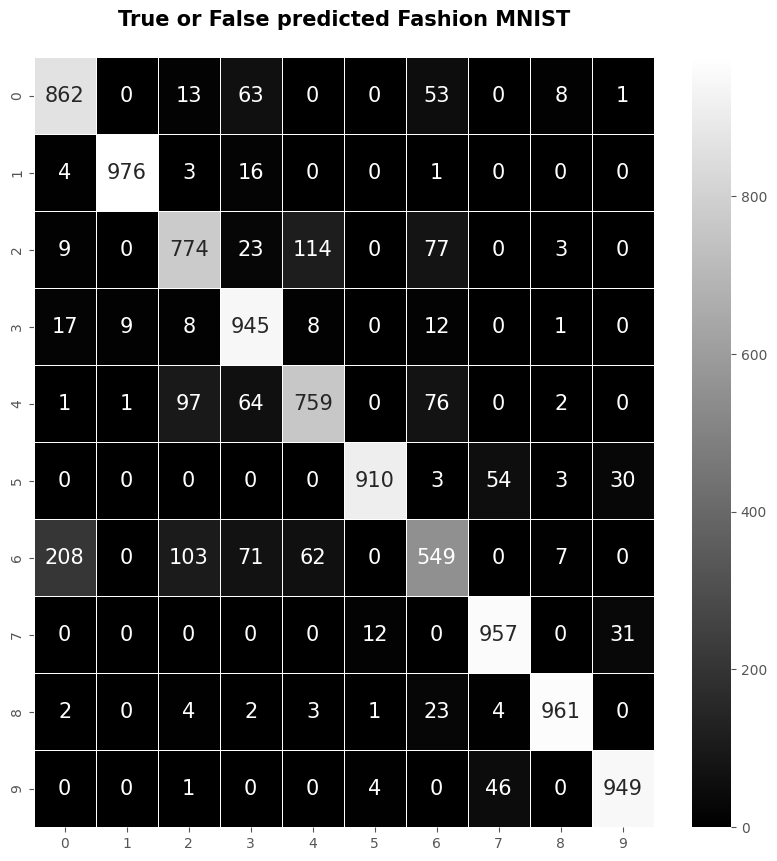

In [24]:
con_mat=confusion_matrix(y_test_fash_eval,y_predict_fash)
plt.style.use('ggplot')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size': 15},linewidths=0.5,fmt="d",cmap="gray")
plt.title('True or False predicted Fashion MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test_fash_eval,y_predict_fash))

              precision    recall  f1-score   support

           0       0.78      0.86      0.82      1000
           1       0.99      0.98      0.98      1000
           2       0.77      0.77      0.77      1000
           3       0.80      0.94      0.87      1000
           4       0.80      0.76      0.78      1000
           5       0.98      0.91      0.94      1000
           6       0.69      0.55      0.61      1000
           7       0.90      0.96      0.93      1000
           8       0.98      0.96      0.97      1000
           9       0.94      0.95      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



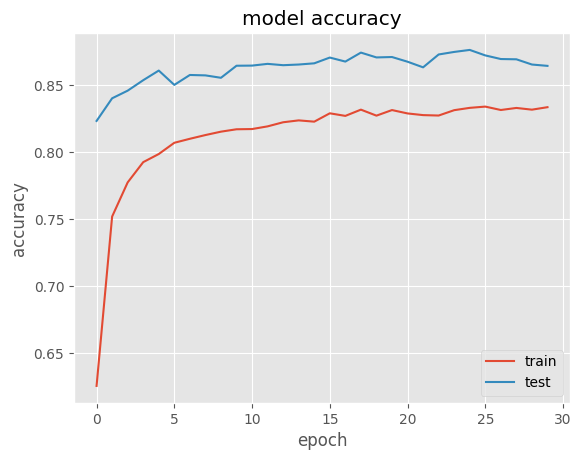

In [26]:
#summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()


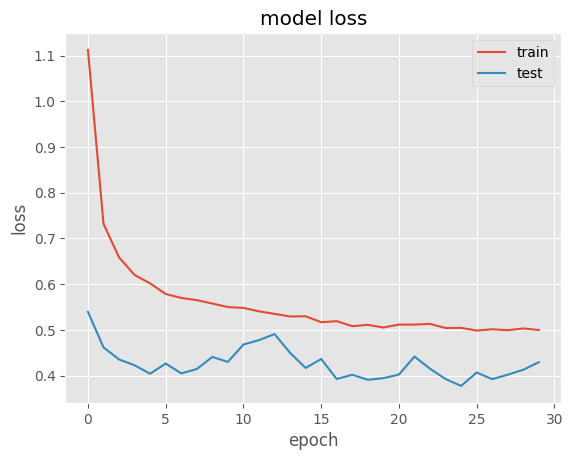

In [27]:
#summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()


In [28]:
#single image checking
y_predict= model.predict(X_test_fashion.loc[[0],:].values)
y_predict = np.argmax(y_predict,axis=1)
y_test_fash_eval = np.argmax(y_test_fashion,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


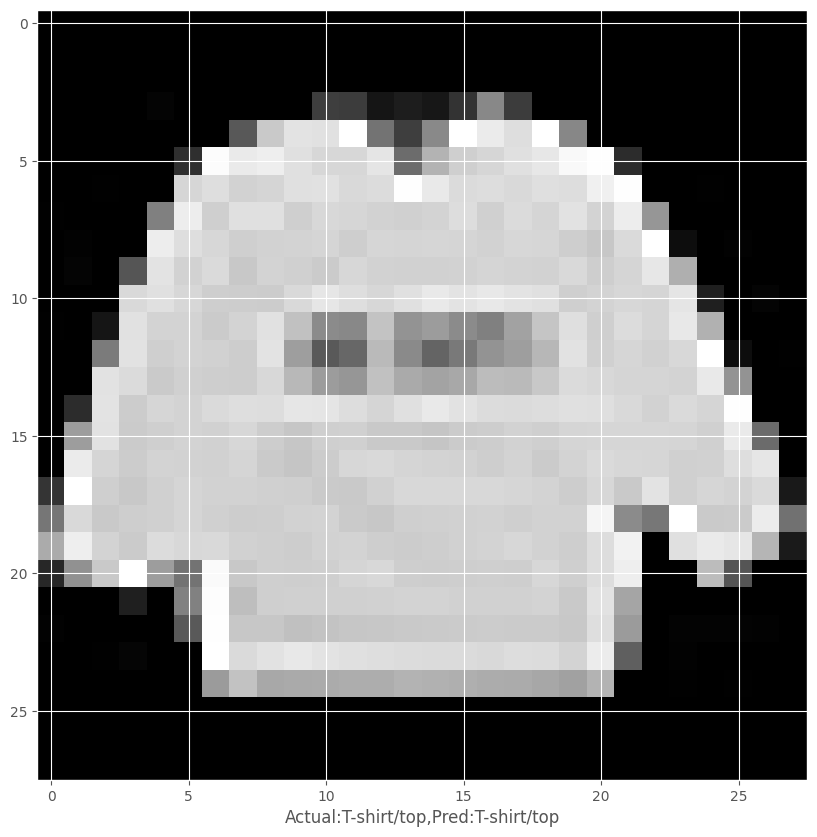

In [29]:
#Names of clothing accessories in order 
col_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

#Visualizing the images
plt.figure(figsize=(10,10))

plt.imshow(x_train_reshape[0], cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[y_test_fash_eval[0]],col_names[y_predict[0]]))
plt.show()